## 3. Exploratory data analysis

In [1]:
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv('../data/cleared-combine-21-23.csv',index_col = 'time', parse_dates = True)
df.head()

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,1,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,1,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,1,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,1,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [3]:
weather = df.iloc[:,1:9]

In [4]:
weather.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco
count,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000
mean,16.715251,10.145323,69.027588,0.048969,160.748782,9.934148,1015.323246,2.690373
std,4.205286,6.234503,19.666028,0.411796,109.163725,7.117350,3.837478,1.878776
min,4.000000,-17.300000,6.000000,0.000000,0.000000,0.000000,996.800000,1.000000
25%,13.900000,7.300000,60.000000,0.000000,50.000000,5.400000,1012.800000,1.000000
50%,16.700000,11.700000,74.000000,0.000000,210.000000,9.400000,1015.000000,2.000000
75%,19.400000,15.000000,84.000000,0.000000,250.000000,14.800000,1017.800000,3.000000
max,40.700000,28.900000,100.000000,10.700000,360.000000,59.400000,1028.900000,18.000000


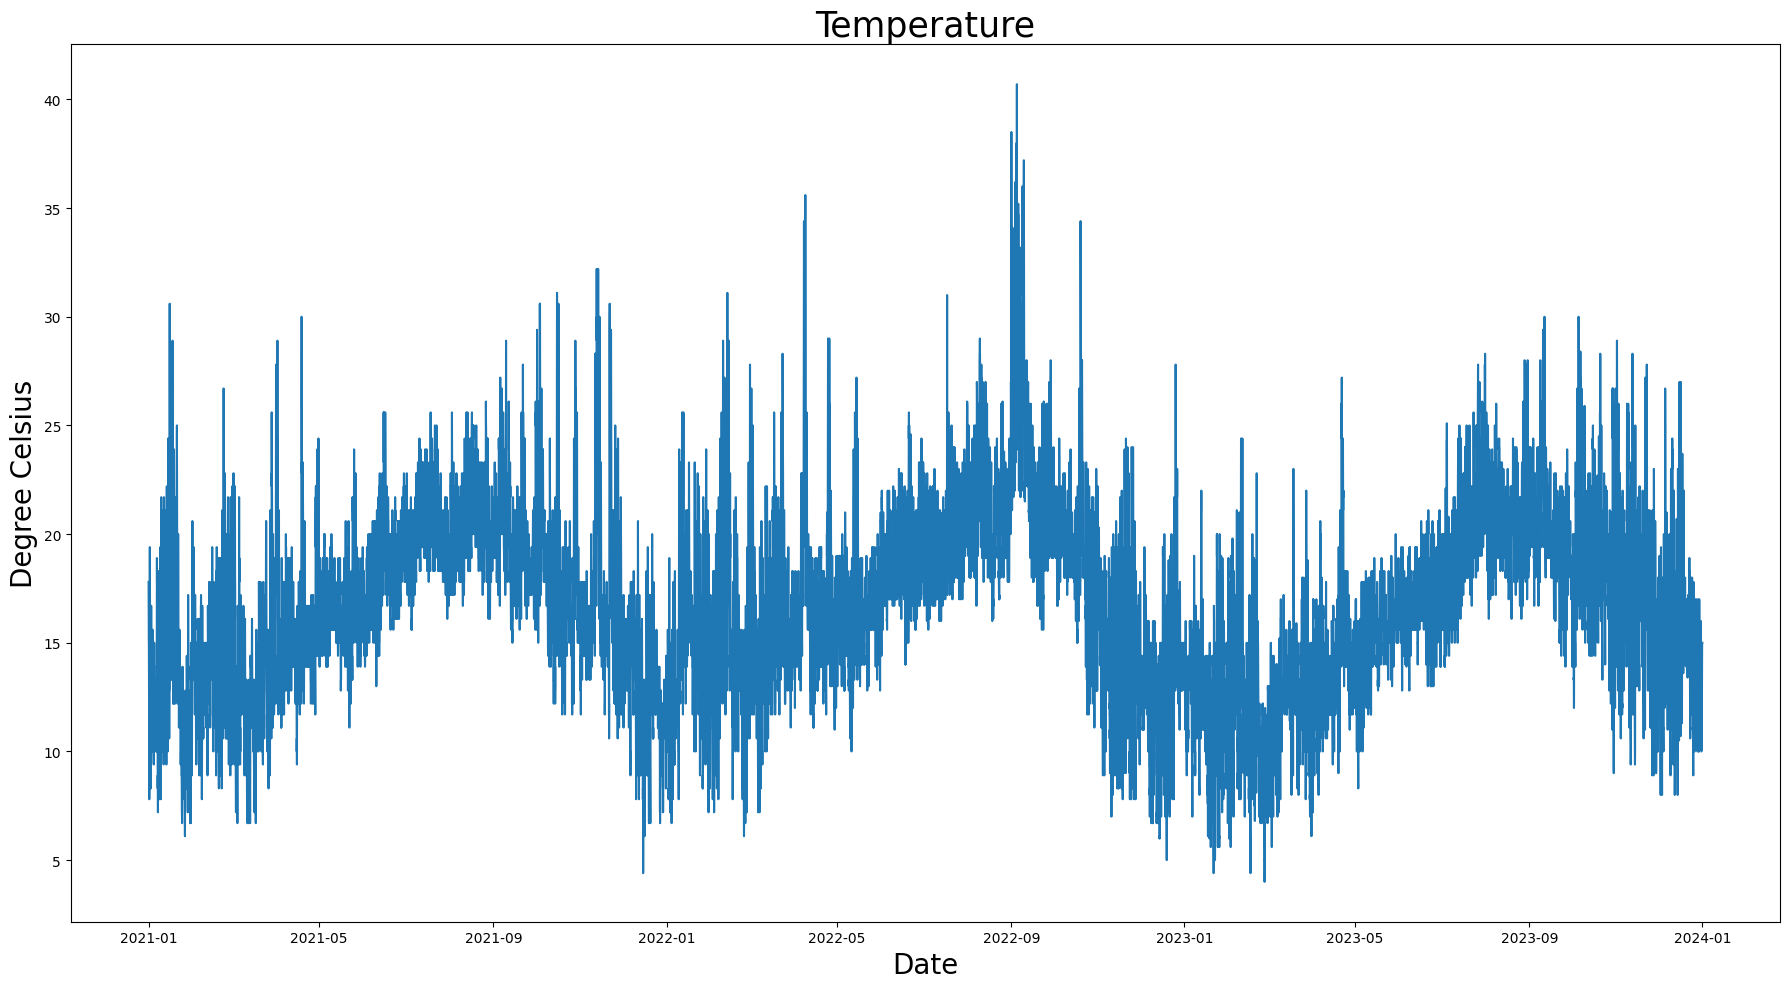

In [5]:
plt.figure(figsize = (18,10))
plt.plot(weather['temp'])

plt.title('Temperature', size = 25)
plt.xlabel('Date', size = 20)
plt.ylabel('Degree Celsius', size = 20)

plt.tight_layout()
plt.savefig('../images/weather-temperature.png');

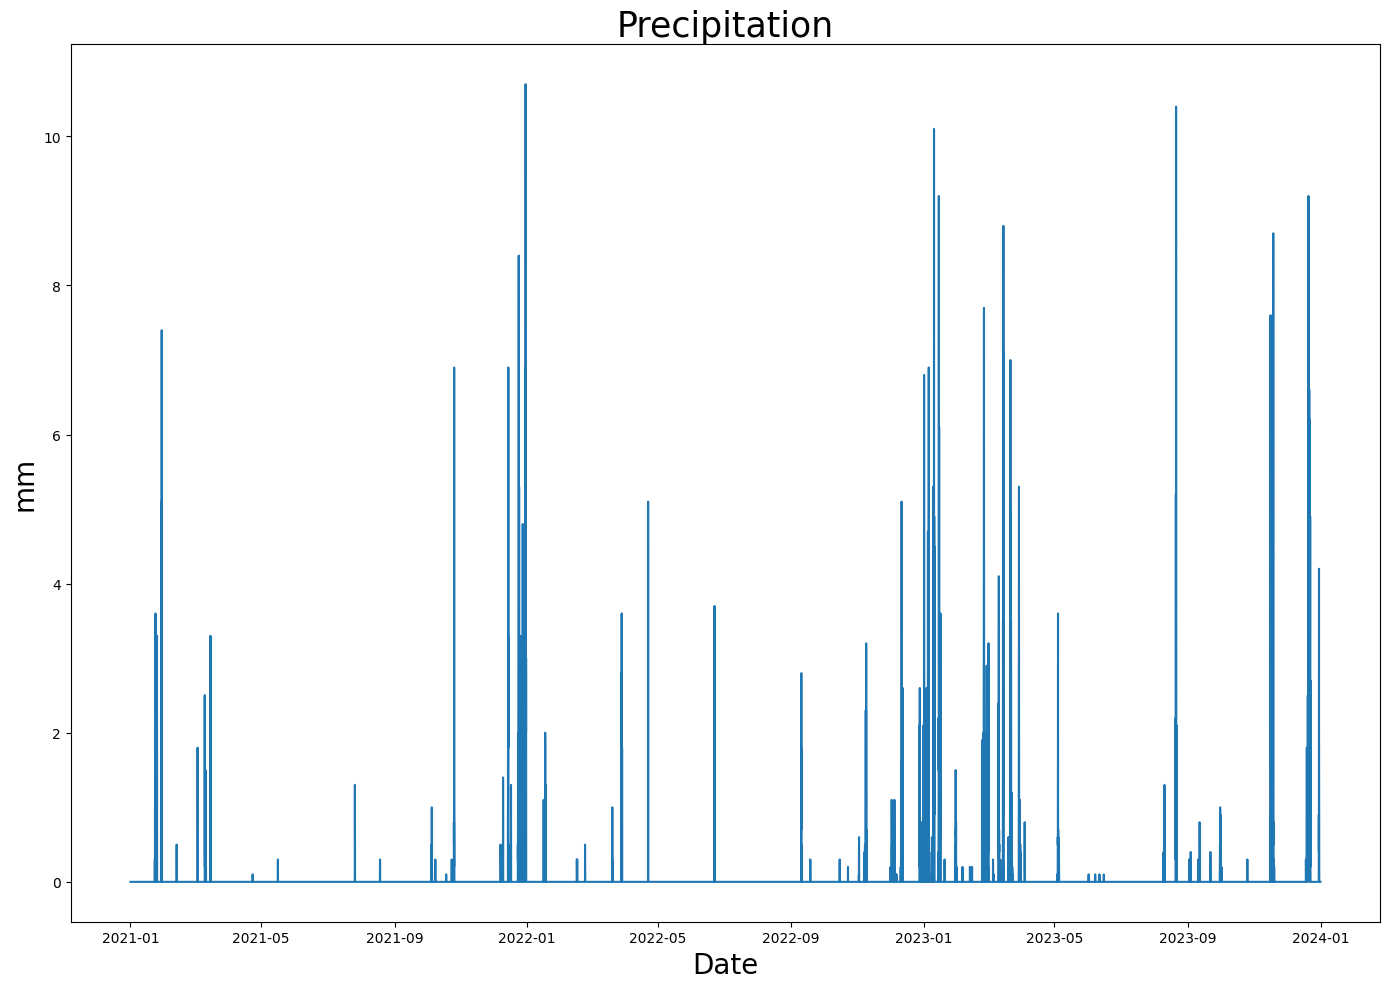

In [6]:
plt.figure(figsize = (14,10))
plt.plot(weather['prcp'])

plt.title('Precipitation', size = 25)
plt.xlabel('Date', size = 20)
plt.ylabel('mm', size = 20)

plt.tight_layout()
plt.savefig('../images/weather-precipitation.png');

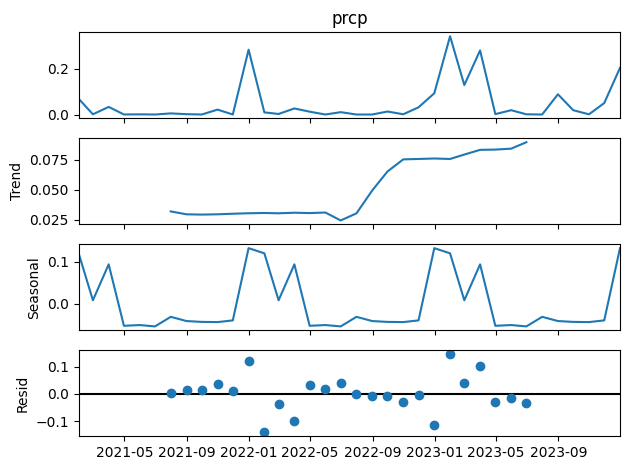

In [7]:
montly_prcp = weather['prcp'].resample('ME').mean()
decomp = seasonal_decompose(montly_prcp)
decomp.plot();

In [8]:
weather['coco'].value_counts()

coco
1.0     7381
2.0     7145
3.0     6516
5.0     3290
4.0      843
7.0      362
9.0      318
8.0      290
17.0      82
6.0       22
18.0      12
11.0       8
10.0       8
12.0       3
Name: count, dtype: int64

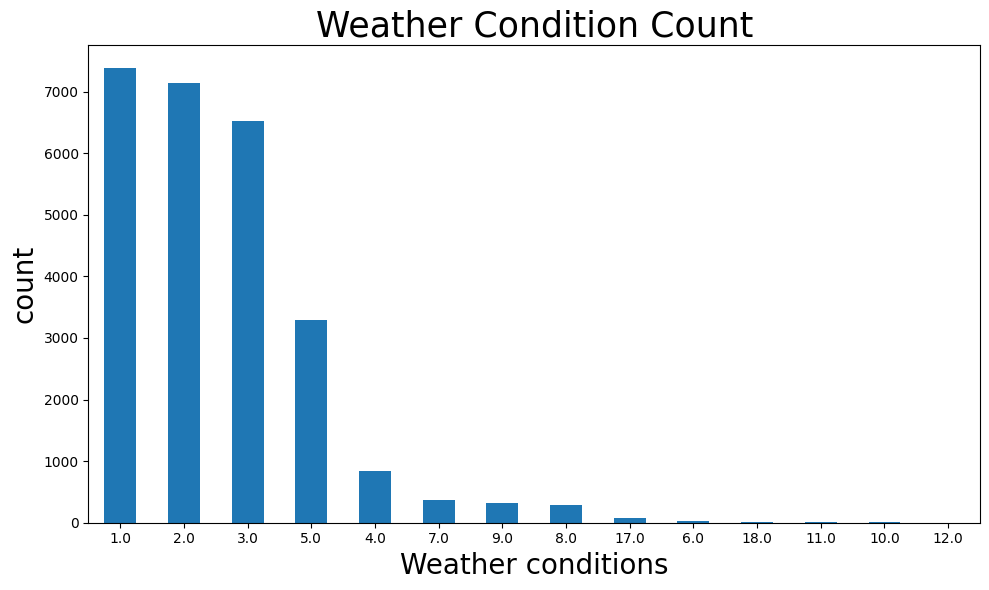

In [9]:
plt.figure(figsize = (10,6))
weather['coco'].value_counts().plot(kind='bar')

plt.title('Weather Condition Count', size = 25)
plt.xticks(rotation = 0)
plt.xlabel('Weather conditions', size = 20)
plt.ylabel('count', size = 20)

plt.tight_layout()
plt.savefig('../images/weather-conditions-code.png');

In [10]:
# randomly choose a station to analyze 
random.seed(42)
random_station = random.choice(df.columns[9:])
random_station

'717801'

In [11]:
station = df[random_station]
station.describe()

count    26280.000000
mean      5426.564784
std       2503.054379
min        191.000000
25%       3392.750000
50%       5753.000000
75%       7360.000000
max      14691.000000
Name: 717801, dtype: float64

### Seasonal decomposition

In [12]:
# hourly
# hourly plot is not readable

In [13]:
# plt.figure(figsize = (18,10))
# plt.plot(station)

# plt.title('Hourly Traffic Volume for Station 761455', size = 20)
# plt.xlabel('Date', size = 15)
# plt.ylabel('Traffic count', size = 15);

In [14]:
# decomp = seasonal_decompose(station)
# decomp.plot();

In [15]:
# daily
day_sample = station.resample('d').mean()

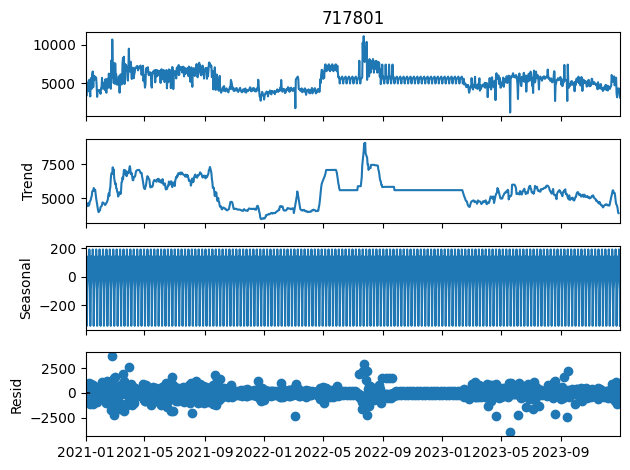

In [16]:
decomp = seasonal_decompose(day_sample)
decomp.plot()

plt.tight_layout()
plt.savefig('../images/seasonal-decompose-daily.png');

In [17]:
# weekly
week_sample = station.resample('W').mean()

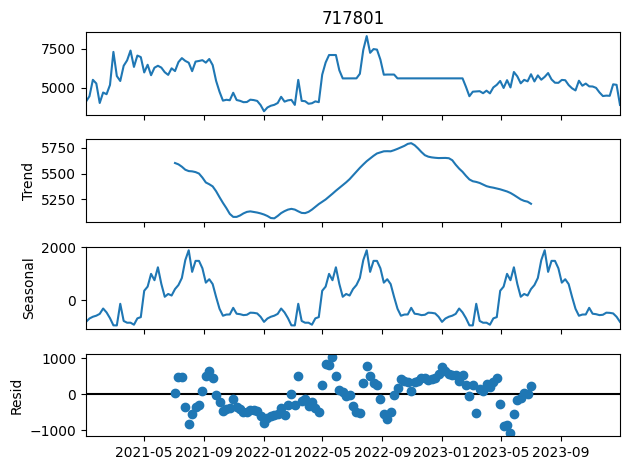

In [18]:
decomp = seasonal_decompose(week_sample)
decomp.plot()

plt.tight_layout()
plt.savefig('../images/seasonal-decompose-weekly.png');

In [19]:
# monthly
month_sample = station.resample('ME').mean()

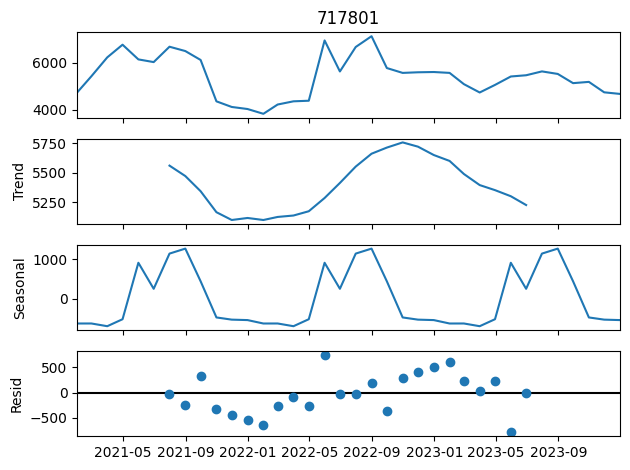

In [20]:
decomp = seasonal_decompose(month_sample)
decomp.plot()

plt.tight_layout()
plt.savefig('../images/seasonal-decompose-monthly.png');

### Correlation

In [21]:
df.corr().round(2)

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
isholiday,1.00,-0.02,-0.08,-0.06,0.02,-0.02,0.01,-0.03,-0.03,-0.03,...,-0.03,-0.02,-0.03,-0.03,-0.03,-0.02,-0.02,-0.03,-0.03,-0.02
temp,-0.02,1.00,0.40,-0.24,-0.10,0.26,0.21,-0.36,-0.12,-0.12,...,0.00,0.01,0.02,-0.04,-0.05,-0.08,-0.07,-0.05,-0.11,-0.21
dwpt,-0.08,0.40,1.00,0.76,0.02,0.10,-0.01,-0.55,0.18,-0.02,...,-0.01,0.03,0.01,-0.03,-0.01,-0.04,-0.07,-0.06,-0.07,-0.06
rhum,-0.06,-0.24,0.76,1.00,0.12,-0.10,-0.20,-0.34,0.31,0.08,...,-0.00,0.03,0.01,0.01,0.04,0.03,-0.01,-0.03,0.02,0.11
prcp,0.02,-0.10,0.02,0.12,1.00,-0.04,0.07,-0.08,0.38,-0.01,...,-0.03,-0.04,-0.03,-0.03,0.00,0.02,-0.02,-0.05,-0.01,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717827,-0.02,-0.08,-0.04,0.03,0.02,-0.30,-0.28,0.07,0.11,0.91,...,0.91,0.87,0.91,0.89,0.97,1.00,0.82,0.71,0.85,0.77
771808,-0.02,-0.07,-0.07,-0.01,-0.02,-0.22,-0.18,0.12,0.07,0.80,...,0.80,0.80,0.82,0.79,0.82,0.82,1.00,0.93,0.82,0.77
771767,-0.03,-0.05,-0.06,-0.03,-0.05,-0.16,-0.13,0.10,0.04,0.69,...,0.75,0.77,0.76,0.76,0.72,0.71,0.93,1.00,0.76,0.68
772011,-0.03,-0.11,-0.07,0.02,-0.01,-0.28,-0.26,0.10,0.08,0.84,...,0.82,0.78,0.82,0.80,0.86,0.85,0.82,0.76,1.00,0.86


Correlation between stations are usually strong but correlation between stations and weather columns are low and some are negatives, which suggests that weater condition may not have very stong influence on traffic flow.

In [22]:
# hourly autocorrelation and partial autocorrelation

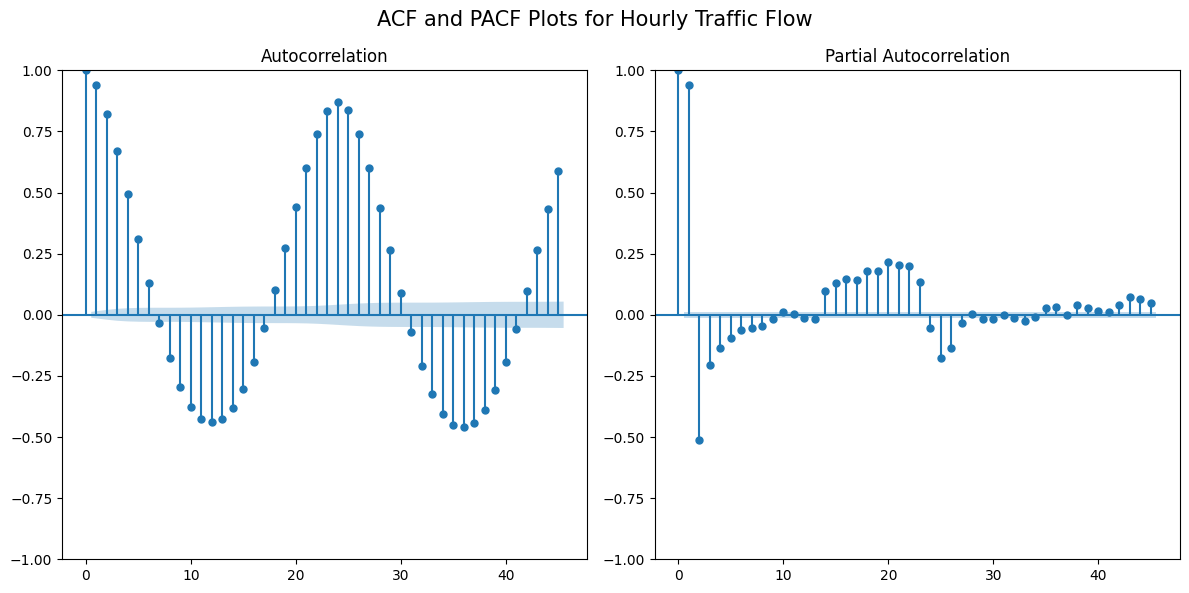

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(station, ax=axes[0])

plot_pacf(station, ax=axes[1])

fig.suptitle('ACF and PACF Plots for Hourly Traffic Flow', fontsize=15)
plt.tight_layout()
plt.savefig('../images/ACF-hourly.png');

Traffic data often exhibits strong time-based dependencies, seasonal patterns, and potential influences from external factors such as weather and day of the week.
* For autocorrelation
    * plot suggests a seasonal pattern in this staion's traffic flow data. Traffic flow data on freeway, often shows regular fluctuations throughout the day and week. The negative autocorrelation at certain lags (like at -0.25) indicates that there might be a period of counter-cyclic behavior. For example, traffic decreases after peak hours as congestion clears up.
    *  A positive autocorrelation value like the 2nd and 3rd lags suggests that the traffic flow at a certain hour (1 or 2 hour before) has a moderate correlation with the current flow. This could be due to carryover effects from previous hours of congestion or clear traffic conditions (e.g., traffic buildup or clearance that persists for some time).
    *  Most value outside the confidence interval indicates that many of the autocorrelations are significant, meaning that the traffic flow data exhibits strong temporal dependencies, and the time series is not random. The autocorrelations outside the confidence interval suggest that traffic flow is not independent from past values.
* For partial autocorrelation
    * High PACF at lag 1: A high PACF value at lag 1 (0.9) suggests that the current traffic flow is directly related to the traffic flow 1 hours prior, with minimal influence from other intermediate hours. This indicates that the relationship between traffic flow at hour t and hour t−1 is significant.
    * PACF drops off after lag 1: The drop-off after lag 1 to small values below zero suggests that higher lags do not provide much additional information after accounting for the first lag. The immediate past values (last 1 hours) are the most predictive for future values.  

The daily, weekly and montly plots below show the similar characteristics as the hourly plots. The immediate past values are the most predictive for future values.

In [24]:
# daily autocorrelation and partial autocorrelation

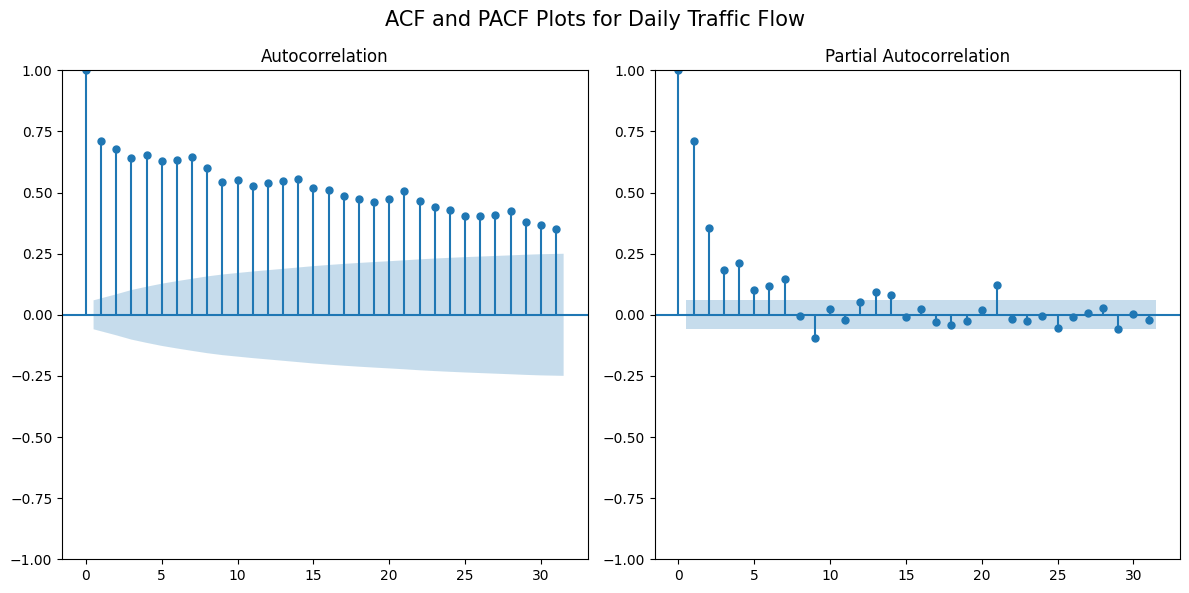

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(day_sample, ax=axes[0], lags=31)

plot_pacf(day_sample, ax=axes[1], lags=31)

fig.suptitle('ACF and PACF Plots for Daily Traffic Flow', fontsize=15)
plt.tight_layout()
plt.savefig('../images/ACF-daily.png');

In [26]:
# weekly autocorrelation and partial autocorrelation

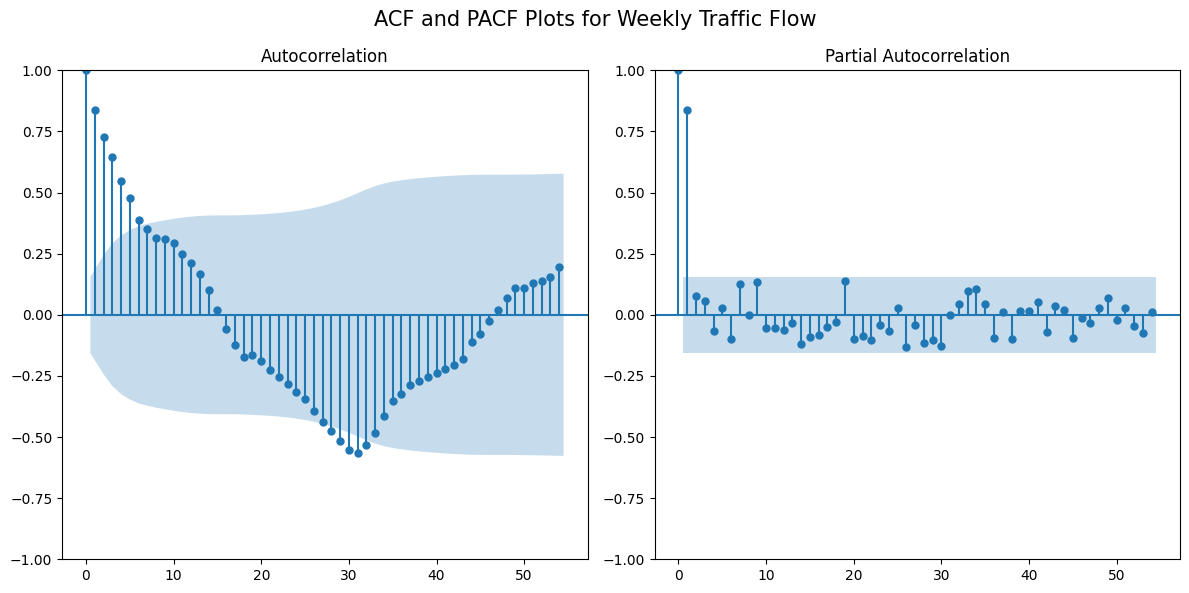

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(week_sample, ax=axes[0], lags=54)

plot_pacf(week_sample, ax=axes[1], lags=54)

fig.suptitle('ACF and PACF Plots for Weekly Traffic Flow', fontsize=15)
plt.tight_layout()
plt.savefig('../images/ACF-weekly.png');

In [28]:
# monthly autocorrelation and partial autocorrelation

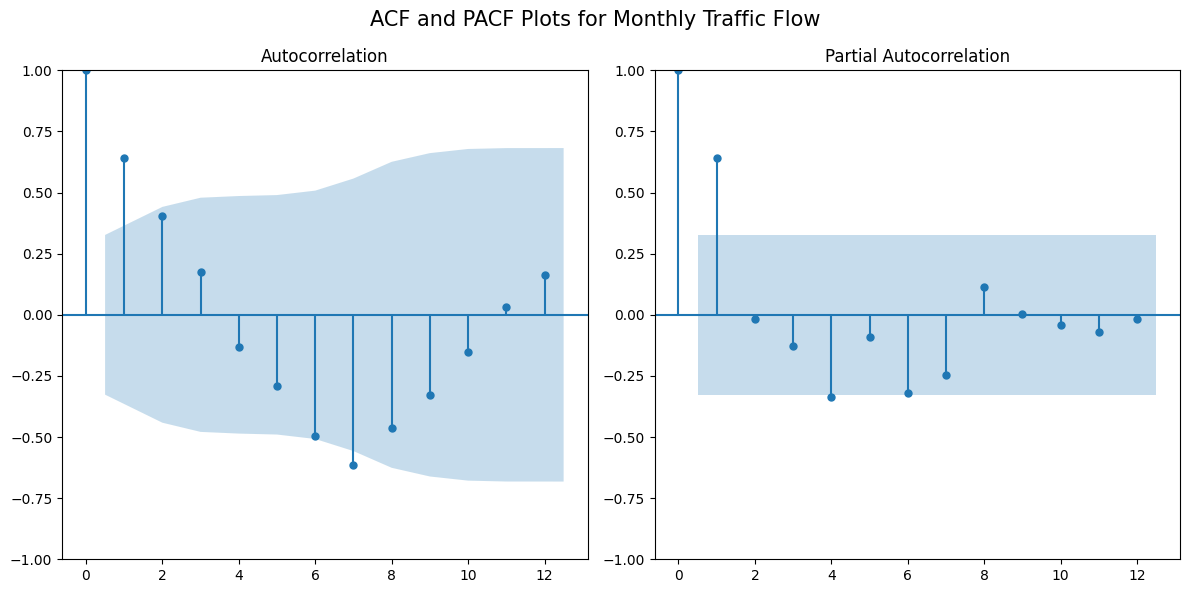

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(month_sample, ax=axes[0], lags=12)

plot_pacf(month_sample, ax=axes[1], lags=12)

fig.suptitle('ACF and PACF Plots for Monthly Traffic Flow', fontsize=15)
plt.tight_layout()
plt.savefig('../images/ACF-monthly.png');

### Stationarity testing

Use Augmented Dickey-Fuller unit root test to check if the data is stationary.

In [30]:
adfuller(station)

(-8.042442737787708,
 1.8316730109499275e-12,
 49,
 26230,
 {'1%': -3.43059933054021,
  '5%': -2.861650196777599,
  '10%': -2.566828654483077},
 408908.1721638808)

* p-value is less than 0.05
* the hourly traffic is stationary

In [31]:
adfuller(day_sample)

(-2.6129603945833226,
 0.09034809354305229,
 20,
 1074,
 {'1%': -3.4364533503600962,
  '5%': -2.864234857527328,
  '10%': -2.568204837482531},
 17060.59228423665)

In [32]:
adfuller(day_sample.diff().dropna())

(-9.900381066581842,
 3.3701934802243074e-17,
 19,
 1074,
 {'1%': -3.4364533503600962,
  '5%': -2.864234857527328,
  '10%': -2.568204837482531},
 17040.980608131566)

* original p-value is larger than 0.05
* the original daily traffic is not stationary
* the daily traffic is stationary after the 1st .diff()

In [33]:
adfuller(week_sample)

(-2.384571537375916,
 0.1461384109919277,
 6,
 150,
 {'1%': -3.474714913481481,
  '5%': -2.881008708148148,
  '10%': -2.5771508444444446},
 2135.9349652798282)

In [34]:
adfuller(week_sample.diff().dropna())

(-6.344228238497572,
 2.707678437867298e-08,
 5,
 150,
 {'1%': -3.474714913481481,
  '5%': -2.881008708148148,
  '10%': -2.5771508444444446},
 2123.197852033947)

* original p-value is larger than 0.05
* the original weekly traffic is not stationary
* the weekly traffic is stationary after the 1st .diff()

In [35]:
adfuller(month_sample)

(-3.254193202444047,
 0.017054396369704013,
 3,
 32,
 {'1%': -3.653519805908203,
  '5%': -2.9572185644531253,
  '10%': -2.6175881640625},
 393.0696524372291)

In [36]:
adfuller(month_sample.diff().dropna())

(-6.633478307543555,
 5.638302915410808e-09,
 0,
 34,
 {'1%': -3.639224104416853,
  '5%': -2.9512301791166293,
  '10%': -2.614446989619377},
 385.2049934880145)

* original p-value is larger than 0.05
* the original monthly traffic is not stationary
* the monthly traffic is stationary after the 1st .diff()